In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
# sys.path.append('./utils/')

import scanpy as sc
import anndata as ad
import scvi
import seaborn as sns
import torch
import gc

### Load three datasets: GSE145926 and GSE158055

In [62]:
GSE145926 = sc.read_h5ad('GSE145926_freshBALF.h5ad')
GSE158055 = sc.read_h5ad("GSE158055_freshBALF.h5ad")

In [63]:
GSE158055 = GSE158055.raw.to_adata()

In [64]:
COVID_all = GSE145926.concatenate(GSE158055)

/tmp/ipykernel_5247/728016289.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  COVID_all = GSE145926.concatenate(GSE158055)


In [65]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [66]:
sc.pp.filter_cells(COVID_all, min_genes=200)  # filtering
sc.pp.filter_genes(COVID_all, min_cells=3)

In [67]:
COVID_all.var["mt"] = COVID_all.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    COVID_all, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

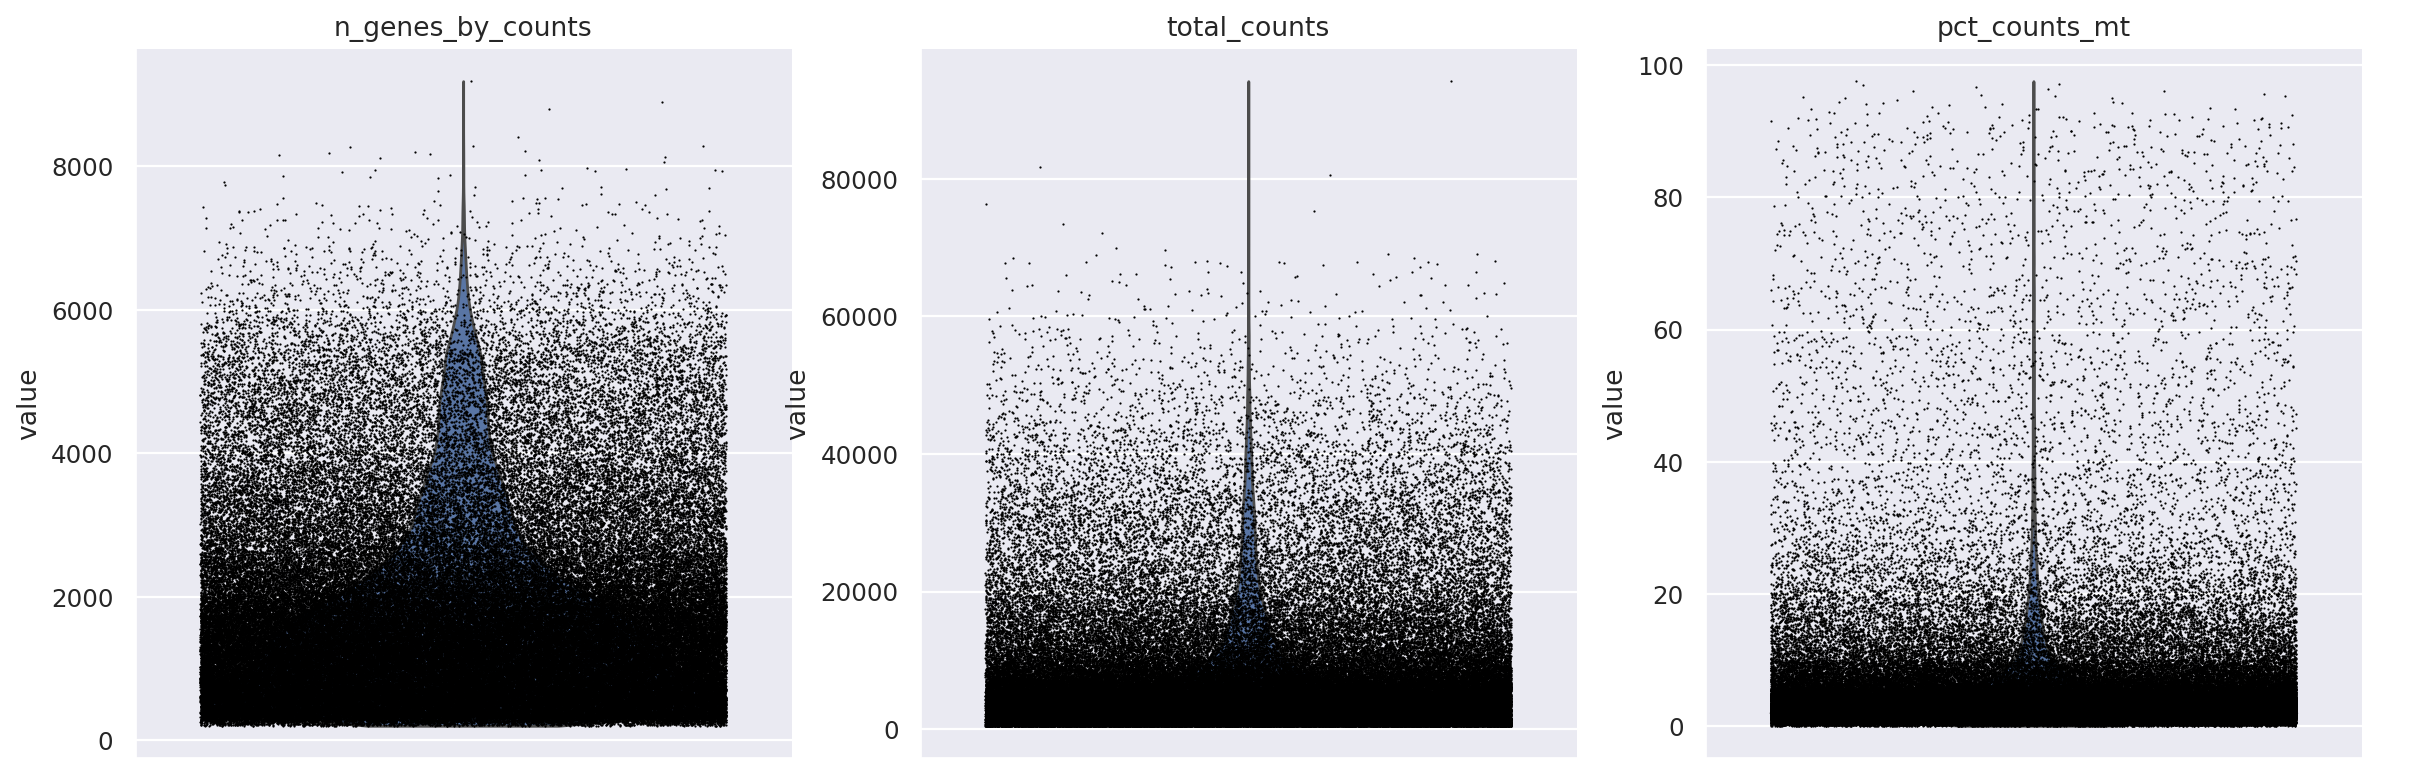

In [68]:
sc.pl.violin(
    COVID_all,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

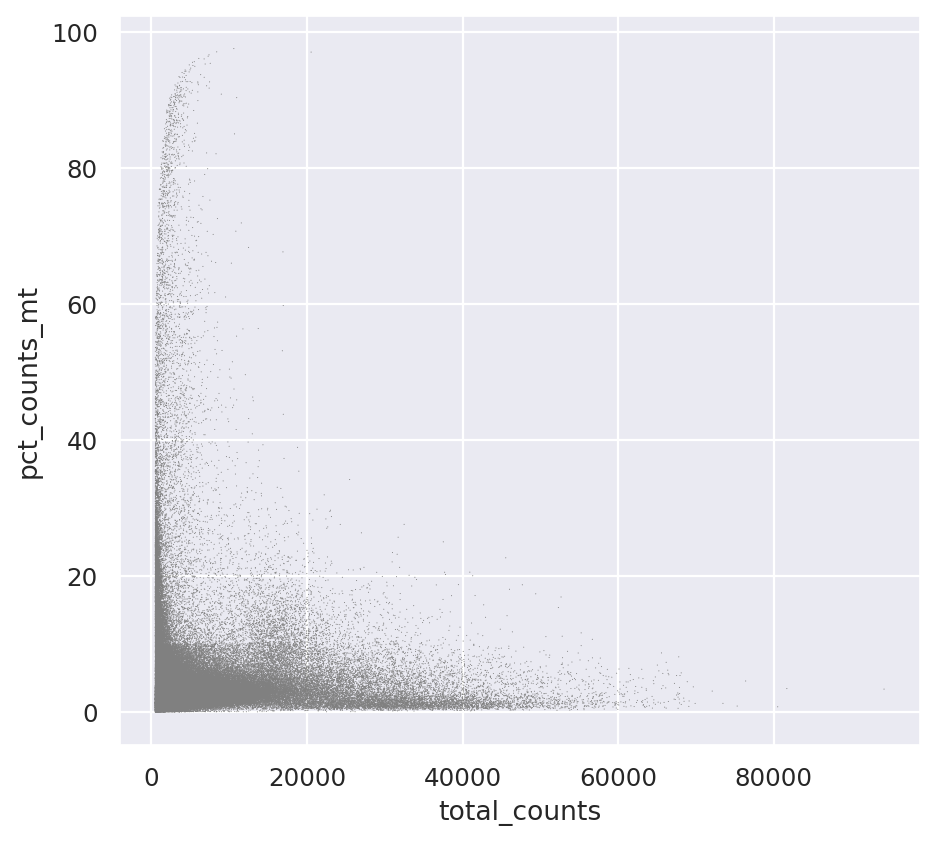

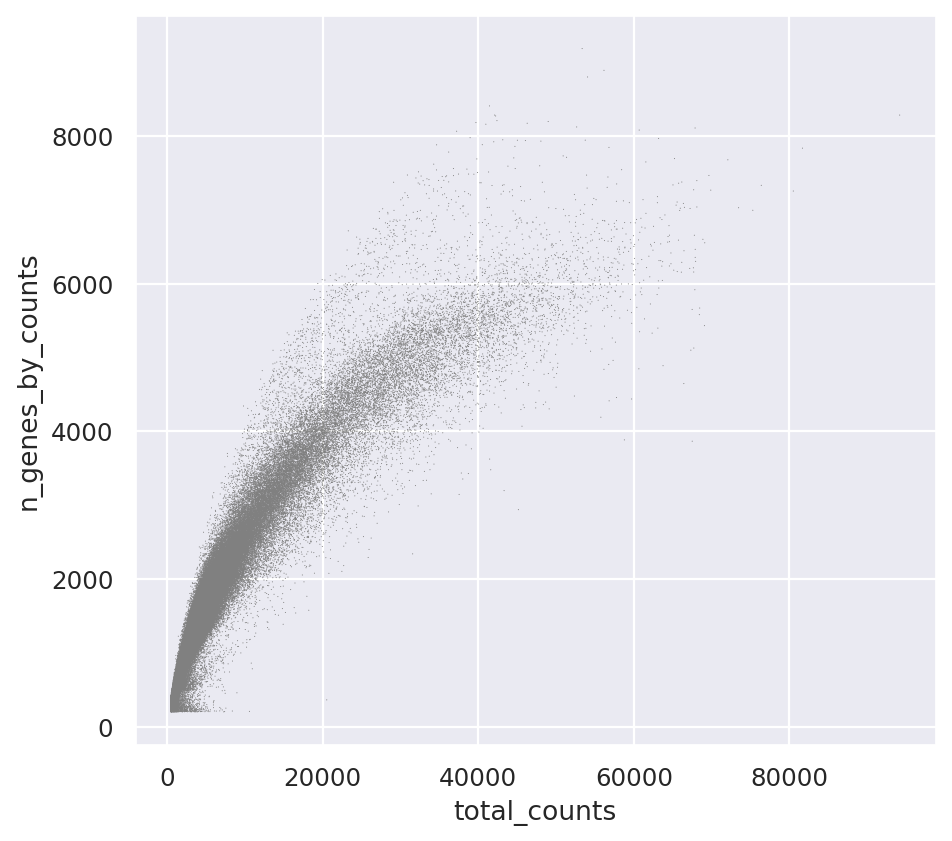

In [69]:
sc.pl.scatter(COVID_all, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(COVID_all, x="total_counts", y="n_genes_by_counts")

In [70]:
COVID_all = COVID_all[COVID_all.obs.n_genes_by_counts < 7000, :]
# according to https://www.biorxiv.org/content/10.1101/2020.02.20.958793v1
# human's mitochondrial ratio has to be higher than 5% (the standard for mice)
# For human tissues, the 5% threshold should be reconsidered as it fails to accurately discriminate between healthy and low-quality cells in 29.5% (13 of 44) tissues analyzed.
COVID_all = COVID_all[COVID_all.obs.pct_counts_mt < 10, :]
COVID_all

View of AnnData object with n_obs × n_vars = 117834 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [71]:
# remove doublet cells
sc.pp.scrublet(COVID_all, batch_key="PatientID", n_prin_comps=50)

/opt/conda/envs/the-project/lib/python3.10/site-packages/scanpy/preprocessing/_scrublet/__init__.py:263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scrubbed_obs = pd.concat([scrub["obs"] for scrub in scrubbed])
/opt/conda/envs/the-project/lib/python3.10/site-packages/scanpy/preprocessing/_scrublet/__init__.py:263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scrubbed_obs = pd.concat([scrub["obs"] for scrub in scrubbed])
/opt/conda/envs/the-project/lib/python3.10/site-packages/scanpy/preproce

In [72]:
COVID_all = COVID_all[COVID_all.obs.predicted_doublet == False]

In [73]:
# saving the raw data to a file
COVID_all.write("COVID_all_qc.h5ad")

/opt/conda/envs/the-project/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/conda/envs/the-project/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/conda/envs/the-project/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/conda/envs/the-project/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/opt/conda/envs/the-project/lib/python3.10/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.